# 3.  Codificación de variables

Conjunto de datos: titanic (incluido en seaborn)

Este conjunto de datos es excelente para trabajar con variables categóricas.

In [58]:
# Importar librerías necesarias
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [59]:
# Cargar el conjunto de datos
data = sns.load_dataset('titanic')

In [60]:
# Visualizar las primeras filas
print("Conjunto de datos Titanic:")
data.head()

Conjunto de datos Titanic:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [61]:
# Seleccionar columnas categóricas
categorical_cols = ['sex', 'embarked', 'class']

In [62]:
# Codificar con LabelEncoder
label_encoder = LabelEncoder()
data['sex_label'] = label_encoder.fit_transform(data['sex'])

In [63]:
# Codificar con OneHotEncoder
onehot_encoder = pd.get_dummies(data['embarked'], prefix='embarked')

In [64]:
# Combinar con el conjunto original
data = pd.concat([data, onehot_encoder], axis=1)

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado. Crea gráficas en donde veas correcto.

### 1. ¿Qué diferencias encuentras entre LabelEncoder y OneHotEncoder?

In [65]:
#LabelEncoder puede hacer que un modelo interprete un orden entre categorías cuando realmente no existe.
#OneHotEncoder evita este problema y representa mejor variables categóricas nominales.

# Mostrar las primeras filas con la codificación LabelEncoder
print("Columna original y codificada:")
print(data[['sex', 'sex_label']].head())

# Mostrar las columnas generadas por OneHotEncoder
print("\nColumnas creadas con OneHotEncoder:")
print(onehot_encoder.head())

Columna original y codificada:
      sex  sex_label
0    male          1
1  female          0
2  female          0
3  female          0
4    male          1

Columnas creadas con OneHotEncoder:
   embarked_C  embarked_Q  embarked_S
0       False       False        True
1        True       False       False
2       False       False        True
3       False       False        True
4       False       False        True


### 2. Crea una gráfica de barras comparando las frecuencias de 'sex' antes y después de la codificación con LabelEncoder.

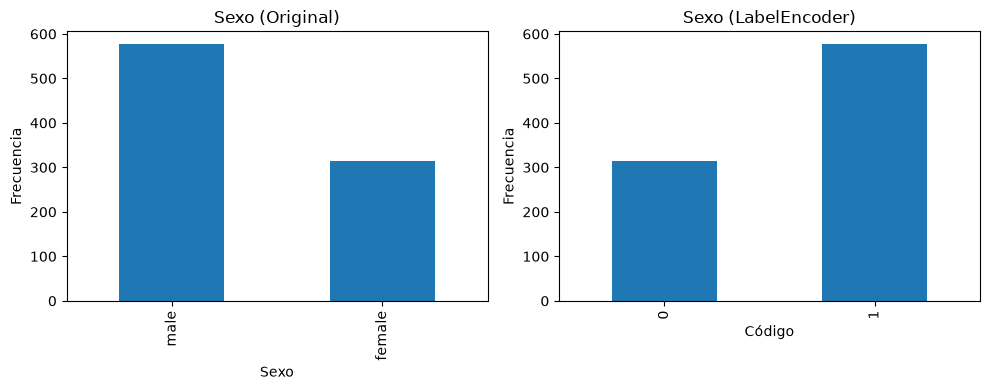

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

# Gráfica original
plt.subplot(1,2,1)
data['sex'].value_counts().plot(kind='bar')
plt.title("Sexo (Original)")
plt.xlabel("Sexo")
plt.ylabel("Frecuencia")

# Gráfica codificada
plt.subplot(1,2,2)
data['sex_label'].value_counts().sort_index().plot(kind='bar')
plt.title("Sexo (LabelEncoder)")
plt.xlabel("Código")
plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()

### 3. Utiliza OneHotEncoder para codificar la columna 'class'. ¿Qué ventajas tiene este enfoque frente a LabelEncoder?

In [67]:
# OneHotEncoder: No asigna un orden artificial netre varialbles, evita que el modelo interprete que una categoría es “mayor” que otra.

# Con OneHotEncoder
class_onehot = pd.get_dummies(data['class'], prefix='class')

# nuevas columnas al DataFrame
data = pd.concat([data, class_onehot], axis=1)

# resultado
print(data[['class', 'class_First', 'class_Second', 'class_Third']].head())

   class  class_First  class_Second  class_Third
0  Third        False         False         True
1  First         True         False        False
2  Third        False         False         True
3  First         True         False        False
4  Third        False         False         True


### 4. Si quisieras aplicar un modelo de aprendizaje automático, ¿qué tipo de codificación elegirías para las variables categóricas? Explica tu respuesta.

In [68]:
# Mostrar las columnas creadas mediante OneHotEncoder
print("Variables codificadas con OneHotEncoder:")
print(data.filter(regex='^embarked_|^class_').head())

Variables codificadas con OneHotEncoder:
   embarked_C  embarked_Q  embarked_S  class_First  class_Second  class_Third
0       False       False        True        False         False         True
1        True       False       False         True         False        False
2       False       False        True        False         False         True
3       False       False        True         True         False        False
4       False       False        True        False         False         True


In [69]:
#Para un modelo de aprendizaje automático elegiría OneHotEncoder para las variables categóricas, porque crea una columna independiente para cada categoría y evita ponerles un orden que en realidad no existe. 
# De esta forma se reduce el riesgo de que el modelo interprete mal las categorias y eso puede mejorar el rendimiento de algoritmos como Regresión Logística, K-Nearest Neighbors, SVM y Redes Neuronales.
#  En cambio, LabelEncoder lo utilizaría cuando las categorías sí tienen un orden definido o cuando se necesita codificar la variable objetivo, ya que en esos casos su uso resulta más conveniente y facil de implementar.